<a href="https://colab.research.google.com/github/oliviapang/DS_3001_Assignments/blob/main/Assignment_5/5_General_Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 1**

1. We use general linear models because in analysis because we can control what types of values the model outputs. This makes the results more interpretable. One advantage they have over linear models is that they can handle non-normal data and non-linear relationships.
2. Binary and categorical cross entropy are effective loss functions for logistic regression because they place a larger penalty on very wrong predictions. If a large, incorrect probability is predicted the loss function goes to infinity.
3. True. It is a general linear model. The logistic function itself is non-linear, but the relationship between the input and log outputs is linear.
4. False. Logistic regression can be used to calculate probabilities, and a threshold can be set such that all probabilities above the threshold are one category and all the values below are another category.
5. No. The input variable b*x is put through a non-linear function, so the calculated coefficient does not directly represent the change per 1 unit.
6. False. Logistic regression is still a linear model, and feature engineering is required to capture the nuances in a relationship.
7. False. Logistic regression is not necessarily "better" than a standard linear model. It simply is better suited to certain tasks such as binary assignment or probability prediction.

**Question 2**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
! git clone https://github.com/ds4e/undergrad_ml_assignments


Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 124 (from 2)
Receiving objects: 100% (126/126), 12.31 MiB | 15.71 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [75]:
# 1
df = pd.read_csv('/content/undergrad_ml_assignments/data/data.csv', sep = ';')

In [76]:
df.columns
columns = ['Debtor','Tuition fees up to date', 'Scholarship holder','Age at enrollment','Curricular units 1st sem (approved)',
      'Target']
df = df.loc[:, columns]
print(df.isna().sum()) # no missing values
df['Dropout'] = df['Target'].apply(lambda x: 0 if x == 'Graduate' or x == 'Enrolled' else 1)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [26]:
# 2
from sklearn.linear_model import LogisticRegression

y = df['Dropout']
X = df.drop(columns = ['Curricular units 1st sem (approved)', 'Target', 'Dropout'])
reg = LogisticRegression(penalty=None,max_iter=5000)
reg = reg.fit(X,y)
pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


Debtor and age at enrollment predict a higher dropout probability while tuition fees up to date and scholarship holder predict a lower dropout probability. Being up to date on tuition does seem to indicate a lower dropout risk.

<Axes: xlabel='Age at enrollment'>

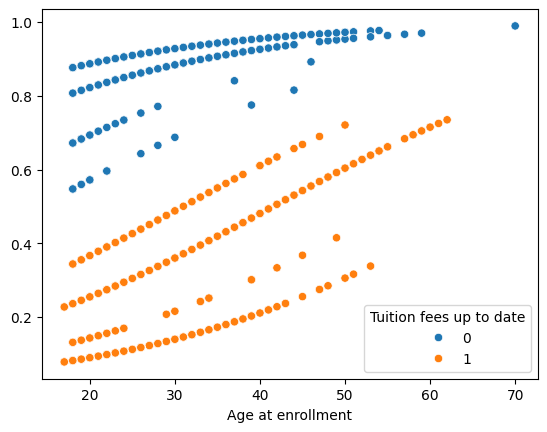

In [33]:
# 3
prob = reg.predict_proba(X)
sns.scatterplot(x = df['Age at enrollment'], y = prob[:, 1], hue = df['Tuition fees up to date'] )
# plot shows probability of being a dropout

Being up to date on tuition seems to reduce dropout probability the most between ages 17 to 25, maybe even 30. On average, being up to date on tuiton reduces the probability of dropout by about 0.5

In [35]:
# 4
y_class = pd.Series(reg.predict(X))

tab = pd.crosstab( y_class, df['Dropout'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Dropout     0    1
row_0             
0        2841  891
1         162  530

Accuracy: 0.7619801084990958


The accuracy is 76.2%

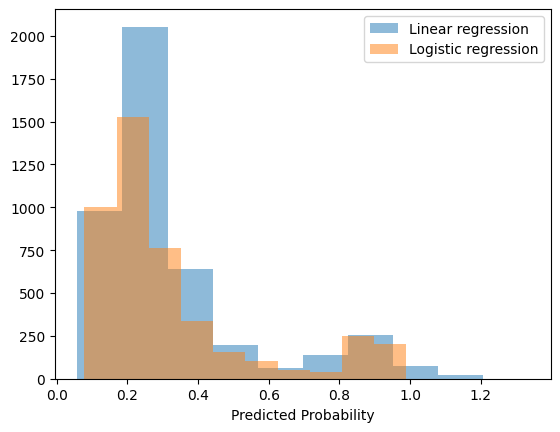

In [38]:
# 5
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X,y)
y_hat = lin_reg.predict(X)

plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=prob[:,1], alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

The linear regression actually seems to have performed fairly well. It follows the shape of the logistic regression closely, except for a few "probabilities" which are over 1.

6. Based on the above work, the students most at risk of dropping out are  older students who are not up to date on tuition, do not have a scholarship, and are in debt. Interventions which could help students stay enrolled include financial aid and financial clarity/flexibility to help ensure students know what and when they have to pay. Additionally, things like free/reduced-cost child care could help those older students who may have children making it hard for them to stay enrolled.

In [56]:
# 7
from sklearn.linear_model import LogisticRegression

features = ['Debtor','Tuition fees up to date', 'Curricular units 1st sem (approved)']
y = df['Target']
X = df.loc[:, features]

mnl = LogisticRegression(penalty=None).fit(X,y)
predicted = mnl.predict(X)

from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(df['Target'], predicted)
tab = pd.DataFrame(cm, index=mnl.classes_, columns=mnl.classes_)
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')
# true values as rows, predicted as columns

Confusion matrix:
           Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Accuracy: 0.7045660036166366


Multinomial regression does a decent job of predicting outcomes. It does well with dropout and graduate, but it did not predict any "enrolled" even though there are 794 enrolled students.

In [74]:
probs = pd.DataFrame(mnl.predict_proba(X))
probs.columns = mnl.classes_
print(probs.head())
print(probs['Enrolled'].max()) # probability of being an enrolled student

    Dropout  Enrolled  Graduate
0  0.680560  0.210486  0.108954
1  0.706615  0.145494  0.147892
2  0.954343  0.040341  0.005316
3  0.117346  0.176786  0.705867
4  0.183691  0.212551  0.603758
0.33022920757182633


There are non-zero probabilites for the "Enrolled" in this case. However, all of the predicted probabilities are pretty low, with the highest being 0.33. Thus, with any reasonable probability threshold "Enrolled" would probably not be predicted, which is why the hard classification never predicted "Enrolled".  

**Question 3**

In [146]:
# 1
df = pd.read_csv('/content/undergrad_ml_assignments/data/cirrhosis.csv')
df.columns
columns = ['Status', 'Drug', 'Edema', 'Bilirubin', 'Stage']
df = df.loc[:, columns]
df.isna().sum()

,0
Status,0
Drug,106
Edema,0
Bilirubin,0
Stage,6


In [147]:
print(df['Drug'])
df['Drug'] = df['Drug'].fillna('Missing')
df['Stage'] = df['Stage'].fillna('Missing')
print(df.isna().sum())

0      D-penicillamine
1      D-penicillamine
2      D-penicillamine
3      D-penicillamine
4              Placebo
            ...       
413                NaN
414                NaN
415                NaN
416                NaN
417                NaN
Name: Drug, Length: 418, dtype: object
Status       0
Drug         0
Edema        0
Bilirubin    0
Stage        0
dtype: int64


Only the drug and stage columns had NaNs, which were replaced with "Missing" to indicate that it is unknown if/what drug the patient received and what stage the dieases was at.  

In [148]:
# 2
map = {'D': 0, 'C': 1, 'CL': 1} # dead is 0, alive is 1
df['Num_Status'] = df['Status'].map(map)
drug_dummies = pd.get_dummies(df['Drug'], prefix='Drug').drop('Drug_Placebo', axis=1)
edema_dummies = pd.get_dummies(df['Edema'], prefix='Edema').drop('Edema_N', axis=1)
y = df['Num_Status']
X = pd.concat([df[['Bilirubin']], drug_dummies, edema_dummies], axis=1)

reg = LogisticRegression(penalty=None,max_iter=5000)
reg = reg.fit(X,y)
pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,Bilirubin,-0.290230
1,Drug_D-penicillamine,-0.234412
2,Drug_Missing,0.172168
3,Edema_S,-0.954177
4,Edema_Y,-2.907604


It does not seem like the drug improves survival probability; the Drug_D coefficient compared to Drug_Placebo. Higher bilirubin indicates lower survival probability and vice versa. Survival rate decreases some for edema resolved with diuretics, and it decreases even more for edema that remains unresolved despite diuretics.

<Axes: xlabel='Bilirubin'>

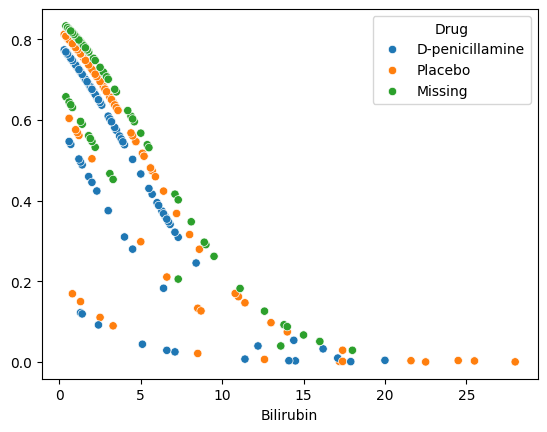

In [149]:
# 3
probs = reg.predict_proba(X)
sns.scatterplot(x = df['Bilirubin'], y = probs[:, 1], hue = df['Drug'] )

In [150]:
X_drug = X.assign(**{'Drug_D-penicillamine': 1, 'Drug_Missing': 0}) # everyone has drug
X_placebo = X.assign(**{'Drug_D-penicillamine': 0, 'Drug_Missing': 0}) # no one has drug
reg = LogisticRegression(penalty=None,max_iter=5000)
reg = reg.fit(X,y)
drug = reg.predict_proba(X_drug)[:, 1]
no_drug = reg.predict_proba(X_placebo)[:, 1]
print(np.mean(drug - no_drug))

-0.043284716097428406


There are no values at which the drug increases survival probability. There is a 4.3% decrease in survival probability if the drug is taken.

In [151]:
# 4
y_class = pd.Series(reg.predict(X))

tab = pd.crosstab( y_class, df['Num_Status'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Num_Status   0    1
row_0              
0           70   20
1           91  237

Accuracy: 0.7344497607655502


The accuracy is 73.44%

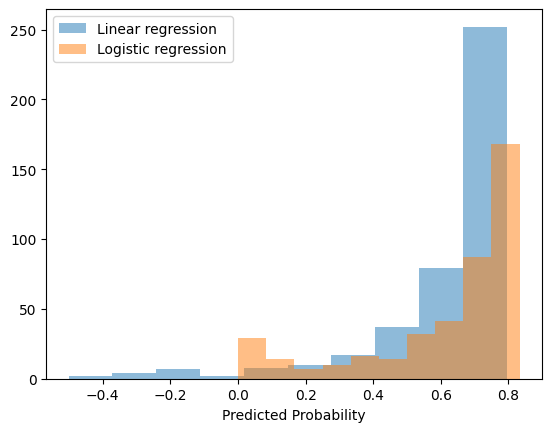

In [152]:
# 5
lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X,y)
y_hat = lin_reg.predict(X)

plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=probs[:,1], alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

The linear regression performs moderately well, although there are a several values which fall below 0 and are not acceptable probabilities.

In [153]:
# 6
'''
y = df['Stage']
X = pd.concat([df[['Bilirubin']], edema_dummies], axis=1)
reg = LogisticRegression(penalty=None,max_iter=5000)
reg = reg.fit(X,y)
pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})
'''

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

array([ 4.,  3.,  2.,  1., nan])